In [1]:
#!pip install -qqq transformers transformers_stream_generator tiktoken transformer_lens einops jaxtyping --progress-bar off

import torch
import functools
import einops
import gc

from datasets import load_dataset
from tqdm import tqdm
from torch import Tensor
from typing import List
from transformer_lens import HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from transformers import AutoModelForCausalLM, AutoTokenizer
from jaxtyping import Float, Int
from collections import defaultdict

# Turn automatic differentiation off to save GPU memory (credit: Undi95)
torch.set_grad_enabled(False)

c:\Users\Admin\miniconda3\envs\training_pt\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\AppData\Local\Temp\ipykernel_38112\2611891530.py:12: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


In [2]:
# Load model and tokenizer
model = HookedTransformer.from_pretrained_no_processing(
    "Qwen/Qwen3-0.6B",
    # local_files_only=True,
    dtype=torch.bfloat16,
    default_padding_side='left'
)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
tokenizer.padding_side = 'left'
tokenizer.pad_token = tokenizer.eos_token

def tokenize_instructions(tokenizer, instructions):
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": instructions}],
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True,
        enable_thinking=False
    ).input_ids

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 11104.45it/s]


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer


## 1. Residual Stream
The residual stream is the backbone of context in LLMs. It is a vector space that every layer reads from and adds to, carrying information from the first layer to the last.


### Layers

A Basic visualization of the residual stream (context) for 1 layer
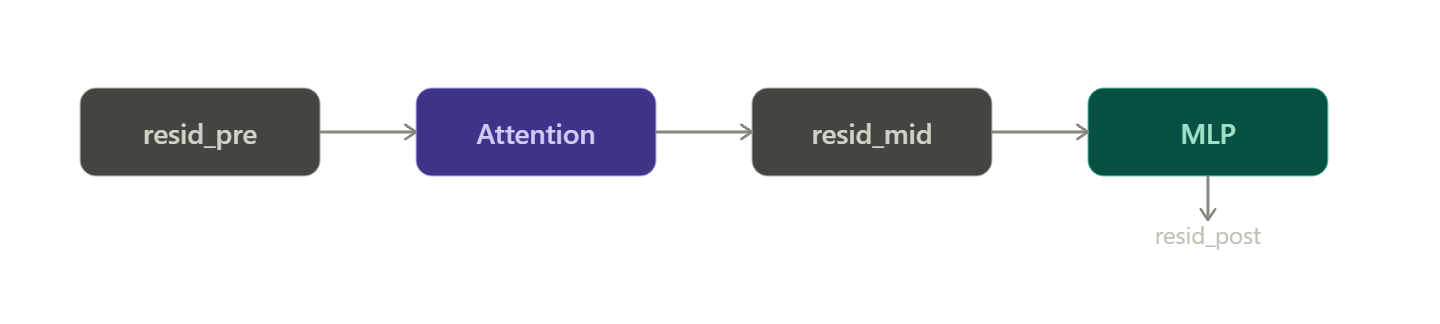

So the input will go the first layer, the output of the layer (resid_post) will be the input of the next layer (resid_pre), and so on and so forth.
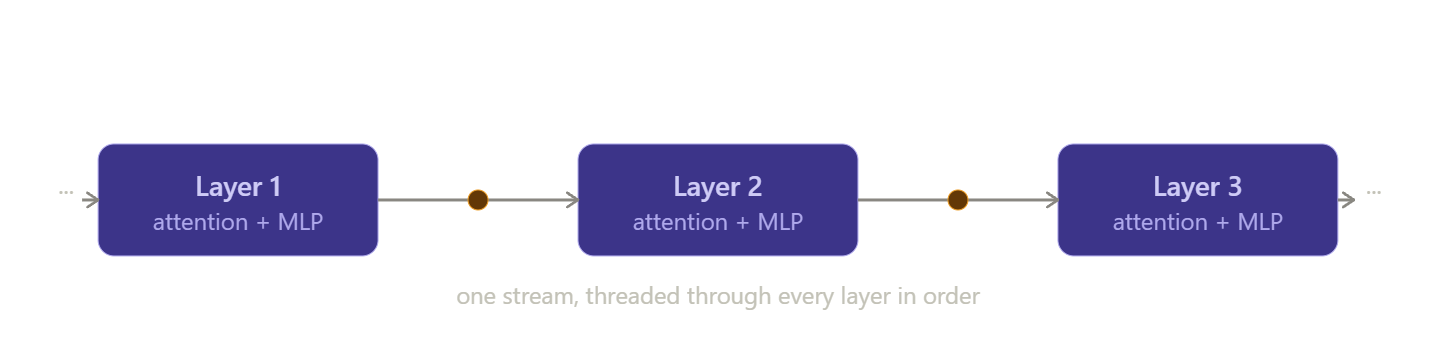

In [3]:
input_tokens = tokenize_instructions(tokenizer, "How do I think?").to(model.cfg.device)

print(tokenizer.decode(model.generate(input_tokens, max_new_tokens=100), skip_special_tokens=True)[0])

 32%|███▏      | 32/100 [00:02<00:05, 13.26it/s]

user
How do I think?
assistant
<think>

</think>

It seems like you might be asking a question that's not clear or properly phrased. Could you please provide more information so I can assist you better?


The model decided from the first token which topic is this and how to respond. All of this is driven from within the model's brain. This tutorial will showcase how to retrieve these values

In [4]:
outputs = model.run_with_cache(
    input_tokens,
    names_filter=lambda hook_name: 'resid' in hook_name, # Only cache the residual stream activations
    reset_hooks_end=True, # Remove the hooks after the forward pass, so the model itself is not modified.
    device='cuda',
    )

# Outputs is a tuple of (logits, cache). The cache is a dictionary of all activations (residual stream values)

In [5]:
tokenizer.decode(outputs[0].argmax(dim=-1)) 
# The model will decide the topic on its first token.

['Question\n嗯 can I find about I\n<|im_start|>\n:\n<think>\nOkay\n\nIf']

In [6]:
residual_stream_activations = outputs[1]
residual_stream_activations.keys()

dict_keys(['blocks.0.hook_resid_pre', 'blocks.0.hook_resid_mid', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.hook_resid_mid', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'blocks.2.hook_resid_mid', 'blocks.2.hook_resid_post', 'blocks.3.hook_resid_pre', 'blocks.3.hook_resid_mid', 'blocks.3.hook_resid_post', 'blocks.4.hook_resid_pre', 'blocks.4.hook_resid_mid', 'blocks.4.hook_resid_post', 'blocks.5.hook_resid_pre', 'blocks.5.hook_resid_mid', 'blocks.5.hook_resid_post', 'blocks.6.hook_resid_pre', 'blocks.6.hook_resid_mid', 'blocks.6.hook_resid_post', 'blocks.7.hook_resid_pre', 'blocks.7.hook_resid_mid', 'blocks.7.hook_resid_post', 'blocks.8.hook_resid_pre', 'blocks.8.hook_resid_mid', 'blocks.8.hook_resid_post', 'blocks.9.hook_resid_pre', 'blocks.9.hook_resid_mid', 'blocks.9.hook_resid_post', 'blocks.10.hook_resid_pre', 'blocks.10.hook_resid_mid', 'blocks.10.hook_resid_post', 'blocks.11.hook_resid_pre', 'blocks.11.hook_resid_mid', 'blocks.11.hook_resid_post',

In [7]:
residual_stream_activations['blocks.0.hook_resid_pre'].shape # [1, tokens, context_space]
context = residual_stream_activations['blocks.0.hook_resid_pre'][0, -1, :] # We only need the last token's context vector

In [8]:
context

tensor([ 0.0018,  0.0286, -0.0493,  ..., -0.0471, -0.0283, -0.0398],
       device='cuda:0', dtype=torch.bfloat16)

The following code will create the complete journey of the context space from entering the model until it is out

Specifically: layer_0_pre --> layer_0_mid --> layer_0_post --> layer_1...

In [9]:
# since resid_post(layer n) = resid_pre(layer n+1) we will not need the pre activations except for the first.
context_journey = []

# Add the first resid_pre
context_journey.append(residual_stream_activations['blocks.0.hook_resid_pre'][0, -1, :])
for activation in residual_stream_activations.items():
    if 'pre' not in activation[0]:
        context_journey.append(activation[1][0, -1, :])

context_journey = torch.stack(context_journey, dim=0)

In [10]:
context_journey.shape # 1 (first pre) + 2 (mid + post per layer) * 28 layers = 57
print(f"The journey of the context in the model's brain is represented into a tensor of shape: {context_journey.shape}")

The journey of the context in the model's brain is represented into a tensor of shape: torch.Size([57, 1024])


In [11]:
import numpy as np, plotly.graph_objects as go

d = context_journey.float().diff(dim=0).cpu().numpy()   # deltas: what each layer ADDS
n_frames, width = d.shape; x = np.arange(width)
ymax = 10

def bar(i):
    return go.Bar(x=x, y=d[i], marker_line_width=0)

frames = [go.Frame(data=[bar(i)], name=str(i)) for i in range(n_frames)]
fig = go.Figure(data=[bar(0)], frames=frames)
fig.update_yaxes(range=[-ymax, ymax])
fig.update_xaxes(range=[0, width-1], dtick=128, title="dimension")   # <-- tick control
fig.update_layout(
    bargap=0,
    sliders=[{"steps": [{"args": [[str(i)], {"frame": {"duration": 0}, "mode": "immediate"}],
                         "label": str(i), "method": "animate"} for i in range(n_frames)]}],
    updatemenus=[{"type": "buttons", "buttons": [
        {"label": "▶", "method": "animate", "args": [None, {"frame": {"duration": 50}, "fromcurrent": True}]},
        {"label": "⏸", "method": "animate", "args": [[None], {"mode": "immediate"}]}]}])
fig.show()

The animation above shows the changes done in the context by each layer. Of course, this by itself serves no real value apart from knowing that most changes are done by later layers. But understanding this will allow us to proceed to the next notebook

### Heads

As shown before, the residual stream and a snapshot of it on each time can show the added value by each component

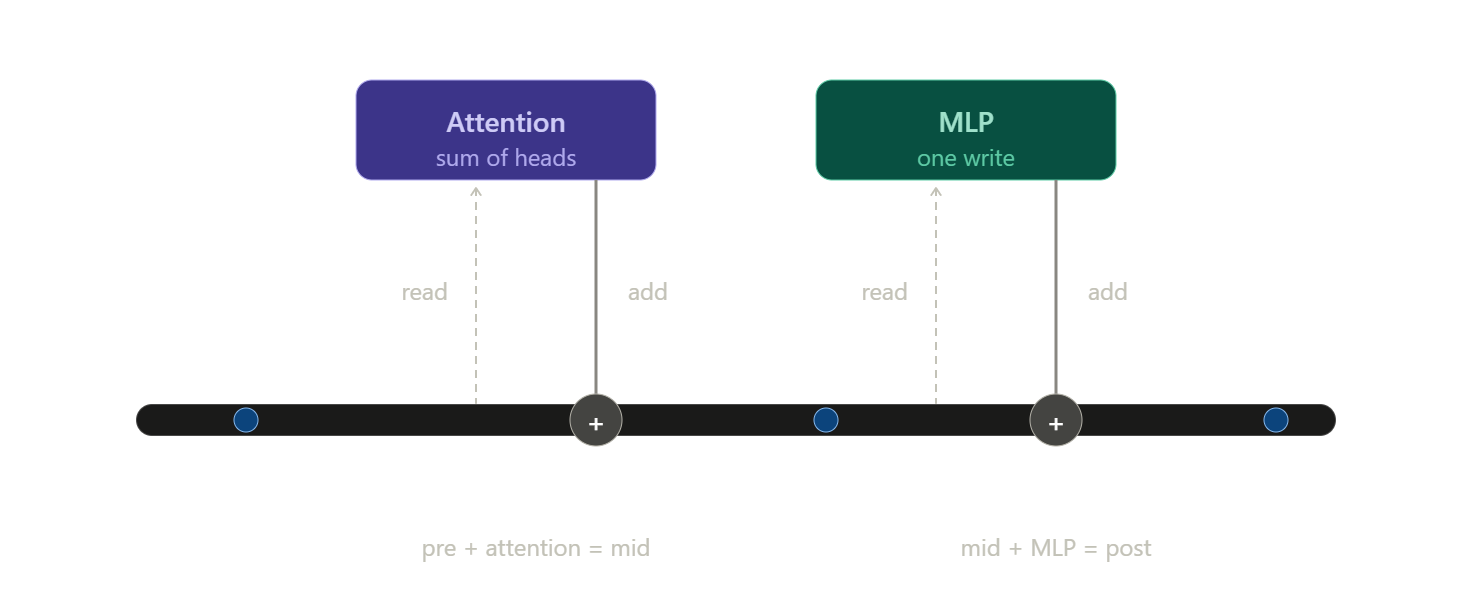

To get even more detailed, we will need to under Attention heads

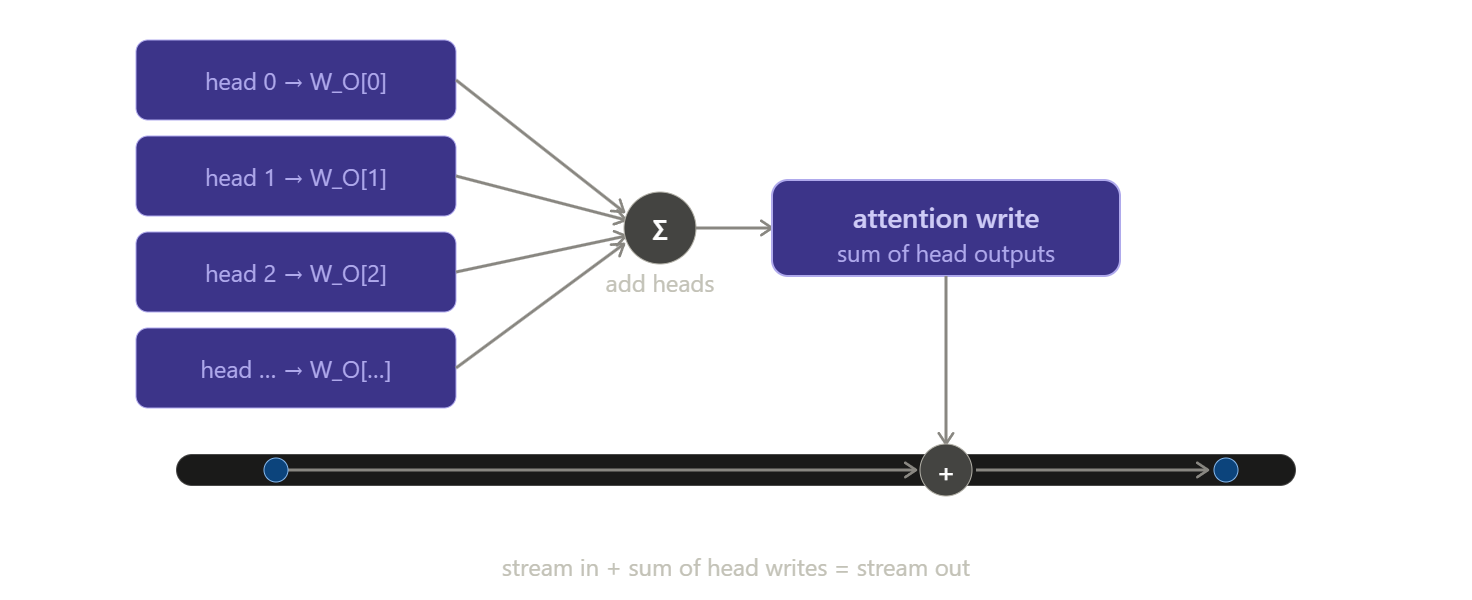

Attention block (the component in the residual stream) is a sum of multiple smaller components called "Heads". Each head has its own weights and operations to add.

So, when we see the output of Attention head (resid_mid - resid_pre), it is the sum of the attention heads of that layer.

In [ ]:
# model.set_use_attn_result(True)          # must be on BEFORE run_with_cache

_, cache = model.run_with_cache(
    input_tokens,
    names_filter=lambda hook_name: True, # Get All hooks
    reset_hooks_end=True, # Remove the hooks after the forward pass, so the model itself is not modified.
    device='cuda',
    )

In [ ]:
cache['blocks.0.attn.hook_z'].shape

torch.Size([1, 17, 16, 128])

: 

In [32]:
[n for n in cache.keys()]

['hook_embed',
 'blocks.0.hook_resid_pre',
 'blocks.0.ln1.hook_scale',
 'blocks.0.ln1.hook_normalized',
 'blocks.0.attn.hook_q',
 'blocks.0.attn.hook_k',
 'blocks.0.attn.hook_v',
 'blocks.0.attn.q_norm.hook_scale',
 'blocks.0.attn.q_norm.hook_normalized',
 'blocks.0.attn.k_norm.hook_scale',
 'blocks.0.attn.k_norm.hook_normalized',
 'blocks.0.attn.hook_rot_q',
 'blocks.0.attn.hook_rot_k',
 'blocks.0.attn.hook_attn_scores',
 'blocks.0.attn.hook_pattern',
 'blocks.0.attn.hook_z',
 'blocks.0.hook_attn_out',
 'blocks.0.hook_resid_mid',
 'blocks.0.ln2.hook_scale',
 'blocks.0.ln2.hook_normalized',
 'blocks.0.mlp.hook_pre',
 'blocks.0.mlp.hook_pre_linear',
 'blocks.0.mlp.hook_post',
 'blocks.0.hook_mlp_out',
 'blocks.0.hook_resid_post',
 'blocks.1.hook_resid_pre',
 'blocks.1.ln1.hook_scale',
 'blocks.1.ln1.hook_normalized',
 'blocks.1.attn.hook_q',
 'blocks.1.attn.hook_k',
 'blocks.1.attn.hook_v',
 'blocks.1.attn.q_norm.hook_scale',
 'blocks.1.attn.q_norm.hook_normalized',
 'blocks.1.attn.k_no